# Titanic Survival Prediction using Ensemble Learning

## Machine Learning Internship – Neurofive Solutions

**Intern:** Amna Shahid

---

### Project Overview

In this project, ensemble learning techniques are applied to predict passenger survival on the Titanic dataset.

Three machine learning models are compared:

- Logistic Regression (Baseline)
- Random Forest
- XGBoost

The models are evaluated using accuracy and feature importance to understand which passenger characteristics contribute most to survival.

In [7]:
# ==========================================
# Import required libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

In [8]:
# ==========================================
# Load Titanic dataset
# ==========================================

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# ==========================================
# Select useful columns
# ==========================================

features = [

    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"

]

target = "Survived"

X = df[features]

y = df[target]

In [10]:
# ==========================================
# Split dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [11]:
# ==========================================
# Numerical and categorical columns
# ==========================================

numeric_features = [

    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Pclass"

]

categorical_features = [

    "Sex",
    "Embarked"

]

# ==========================================
# Numerical preprocessing
# ==========================================

numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

# ==========================================
# Categorical preprocessing
# ==========================================

categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

# ==========================================
# Combine preprocessing
# ==========================================

preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numeric_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)

In [12]:
# ==========================================
# Logistic Regression
# ==========================================

lr_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier", LogisticRegression(max_iter=1000))

    ]

)

lr_pipeline.fit(X_train, y_train)

lr_predictions = lr_pipeline.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy,4))
print()
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.8101

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [13]:
# ==========================================
# Random Forest
# ==========================================

rf_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier", RandomForestClassifier(

            n_estimators=100,

            random_state=42

        ))

    ]

)

rf_pipeline.fit(X_train,y_train)

rf_predictions = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_predictions)

print("Random Forest Accuracy:",round(rf_accuracy,4))
print()

print(classification_report(y_test,rf_predictions))

Random Forest Accuracy: 0.8156

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [14]:
# ==========================================
# XGBoost
# ==========================================

xgb_pipeline = Pipeline(

    steps=[

        ("preprocessor",preprocessor),

        ("classifier",

         XGBClassifier(

             n_estimators=100,

             learning_rate=0.1,

             max_depth=3,

             random_state=42,

             eval_metric="logloss"

         ))

    ]

)

xgb_pipeline.fit(X_train,y_train)

xgb_predictions = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(y_test,xgb_predictions)

print("XGBoost Accuracy:",round(xgb_accuracy,4))
print()

print(classification_report(y_test,xgb_predictions))

XGBoost Accuracy: 0.8156

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



In [15]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Random Forest",

        "XGBoost"

    ],

    "Accuracy":[

        round(lr_accuracy,4),

        round(rf_accuracy,4),

        round(xgb_accuracy,4)

    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.8101
1,Random Forest,0.8156
2,XGBoost,0.8156


In [16]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

rf_importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":rf_pipeline.named_steps["classifier"].feature_importances_

})

rf_importance = rf_importance.sort_values(

    by="Importance",

    ascending=False

)

rf_importance.head(10)

,Feature,Importance
1,num__Fare,0.264150
0,num__Age,0.245507
6,cat__Sex_male,0.157847
5,cat__Sex_female,0.127523
4,num__Pclass,0.083469
2,num__SibSp,0.051097
3,num__Parch,0.034774
9,cat__Embarked_S,0.014873
7,cat__Embarked_C,0.012383
8,cat__Embarked_Q,0.008377


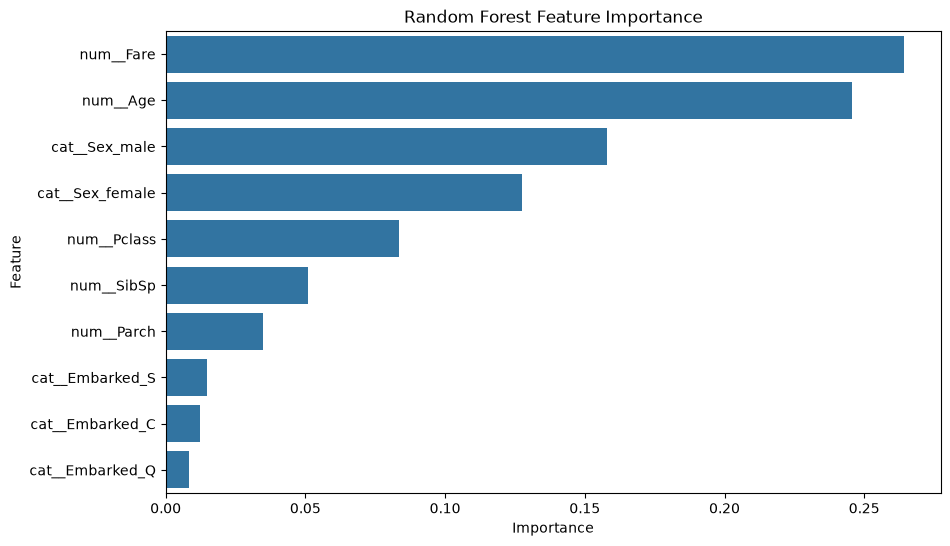

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=rf_importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.show()

In [18]:
xgb_importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":xgb_pipeline.named_steps["classifier"].feature_importances_

})

xgb_importance = xgb_importance.sort_values(

    by="Importance",

    ascending=False

)

xgb_importance.head(10)

,Feature,Importance
5,cat__Sex_female,0.504917
4,num__Pclass,0.221259
2,num__SibSp,0.067623
9,cat__Embarked_S,0.061037
1,num__Fare,0.046099
0,num__Age,0.042830
7,cat__Embarked_C,0.034449
3,num__Parch,0.021787
6,cat__Sex_male,0.000000
8,cat__Embarked_Q,0.000000


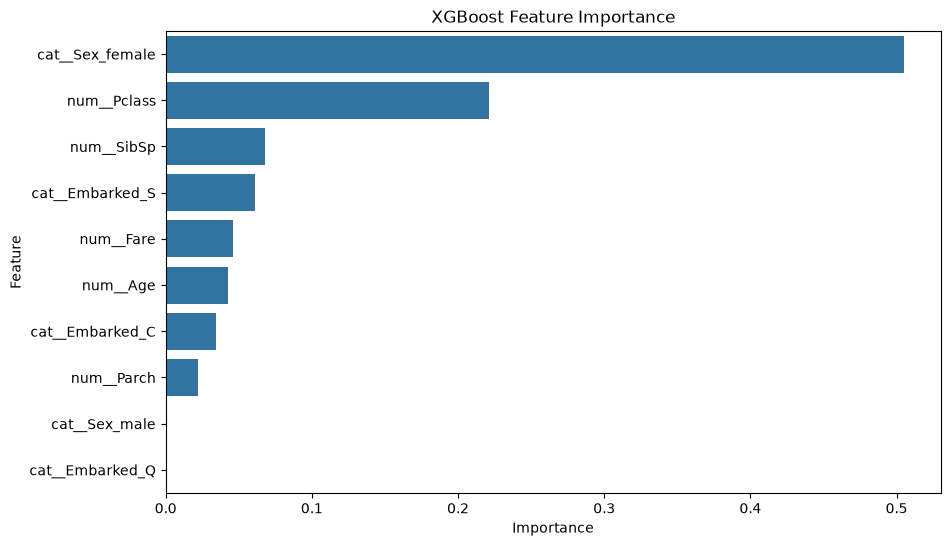

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=xgb_importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("XGBoost Feature Importance")

plt.show()

# Difference Between Random Forest and XGBoost

Random Forest creates many independent decision trees and combines their predictions using majority voting. This reduces overfitting and improves model stability.

XGBoost builds trees sequentially, where each new tree focuses on correcting the mistakes of previous trees. As a result, XGBoost often achieves higher predictive accuracy but requires more computation and tuning.

# Conclusion

Three classification models were trained to predict Titanic passenger survival.

Random Forest and XGBoost were compared with Logistic Regression to evaluate the benefits of ensemble learning. Feature importance analysis showed which passenger attributes had the greatest influence on survival prediction. Ensemble models generally provided stronger predictive performance than the baseline model.